# Tech Challenge — Classificação da Qualidade de Vinhos com Machine Learning

## Objetivo do Projeto

O objetivo deste projeto é desenvolver modelos de Machine Learning capazes de prever a qualidade de vinhos com base em características físico-químicas.

Para simplificar o problema, a variável alvo foi transformada em uma classificação binária:

- Alta Qualidade → nota ≥ 7
- Baixa/Média Qualidade → nota < 7

A análise busca identificar padrões relevantes nos dados e avaliar quais características possuem maior influência na qualidade do vinho.

In [ ]:
import sys
sys.path.append('../src')

from preprocessamento import carregar_dados


In [3]:
from preprocessamento import carregar_dados

import sys

sys.path.append("../src")

from preprocessamento import carregar_dados
from modelagem import (
    criar_modelo_logistico,
    criar_modelo_random_forest
)

In [4]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.model_selection import GridSearchCV


In [5]:
df = carregar_dados("../data/winequality-red.csv")

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [7]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

## Transformação da variável alvo

A variável de qualidade foi transformada em uma classificação binária:

- 1 → vinho de alta qualidade (nota ≥ 7)
- 0 → vinho de baixa/média qualidade (nota < 7)

In [8]:
df = df.drop(columns=['Id'])

df['quality_binary'] = np.where(
    df['quality'] >= 7,
    1,
    0
)

In [9]:
df.shape

(1143, 13)

## Balanceamento das classes

Nesta etapa analisamos a distribuição das classes para verificar possível desbalanceamento entre vinhos de alta e baixa qualidade.

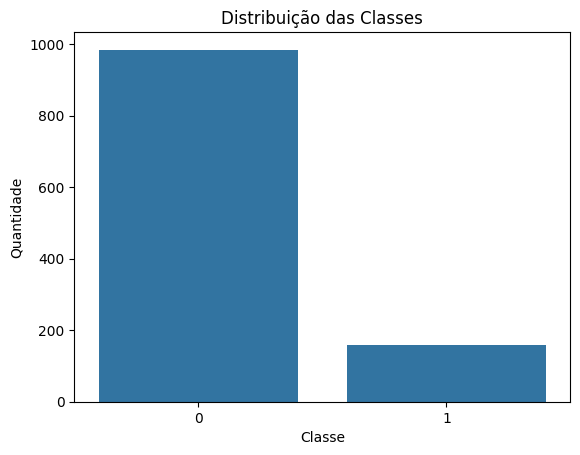

In [10]:
sns.countplot(
    x='quality_binary',
    data=df
)

plt.title(
    'Distribuição das Classes'
)

plt.xlabel(
    'Classe'
)

plt.ylabel(
    'Quantidade'
)

plt.savefig(
    "../results/distribuicao_classes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Análise do Balanceamento

Observa-se um desbalanceamento entre as classes, com predominância de vinhos classificados como baixa/média qualidade.

Esse comportamento é esperado em cenários reais, onde produtos considerados de alta qualidade representam uma parcela menor da produção.

O desbalanceamento pode impactar o desempenho dos modelos de Machine Learning, tornando importante a utilização de métricas além da acurácia para avaliação dos resultados.

## Correlação entre Variáveis

Nesta etapa analisamos a correlação entre as variáveis numéricas do dataset.

O objetivo é identificar relações importantes entre atributos físico-químicos e compreender quais características possuem maior associação com a qualidade dos vinhos.

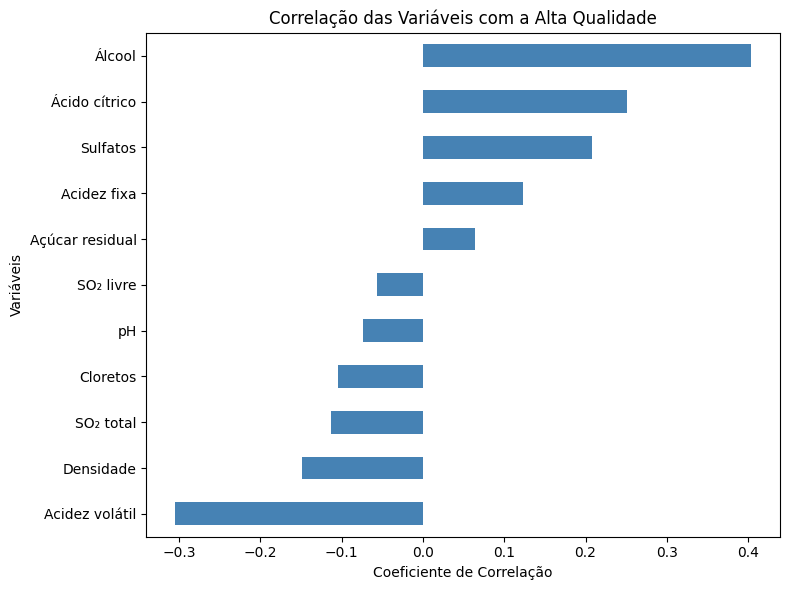

In [11]:
colunas_traduzidas = {
    'fixed acidity': 'Acidez fixa',
    'volatile acidity': 'Acidez volátil',
    'citric acid': 'Ácido cítrico',
    'residual sugar': 'Açúcar residual',
    'chlorides': 'Cloretos',
    'free sulfur dioxide': 'SO₂ livre',
    'total sulfur dioxide': 'SO₂ total',
    'density': 'Densidade',
    'pH': 'pH',
    'sulphates': 'Sulfatos',
    'alcohol': 'Álcool',
    'quality': 'Qualidade',
    'quality_binary': 'Alta qualidade'
}

df_traduzido = df.rename(columns=colunas_traduzidas)

df_corr = df_traduzido.drop(columns=['Qualidade'])

correlacao = (
    df_corr
    .corr(numeric_only=True)['Alta qualidade']
    .drop('Alta qualidade')
    .sort_values()
)

plt.figure(figsize=(8,6))
correlacao.plot(kind='barh', color='steelblue')

plt.title('Correlação das Variáveis com a Alta Qualidade')
plt.xlabel('Coeficiente de Correlação')
plt.ylabel('Variáveis')

plt.tight_layout()

plt.savefig(
    "../results/Correlacao_das_Variaveis_com_a_Alta_Qualidade.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Análise das Correlações

A análise de correlação demonstra que algumas variáveis apresentam associação relevante com a qualidade do vinho.

O teor alcoólico apresentou correlação positiva com a qualidade, indicando que vinhos com maior teor alcoólico tendem a receber melhores avaliações.

Por outro lado, a acidez volátil apresentou correlação negativa, sugerindo impacto desfavorável na percepção de qualidade.

Esses padrões reforçam a importância das características físico-químicas no processo de avaliação dos vinhos e ajudam a compreender quais atributos podem influenciar os modelos de Machine Learning.

# Modelagem de Machine Learning

Após a etapa de análise exploratória, inicia-se o processo de modelagem de Machine Learning.

O objetivo é desenvolver modelos capazes de prever se um vinho será classificado como alta qualidade ou baixa/média qualidade com base em suas características físico-químicas.

In [12]:
X = df.drop(
    ['quality', 'quality_binary'],
    axis=1
)

y = df['quality_binary']

## Separação dos Dados em Treino e Teste

Os dados foram divididos em conjuntos de treino e teste.

O conjunto de treino será utilizado para ensinar o modelo, enquanto o conjunto de teste será utilizado para avaliar sua capacidade de generalização em dados não vistos anteriormente.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
print(X_train.shape)
print(X_test.shape)

(914, 11)
(229, 11)


## Padronização das Variáveis

As variáveis numéricas foram padronizadas utilizando StandardScaler.

Esse processo é importante para algoritmos que são sensíveis à escala das variáveis, garantindo melhor desempenho e estabilidade durante o treinamento.

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# Modelo 1 — Logistic Regression

A Regressão Logística foi utilizada como modelo baseline para classificação.

Esse algoritmo é amplamente utilizado em problemas de classificação binária devido à sua simplicidade, interpretabilidade e eficiência.

In [16]:
lr = criar_modelo_logistico()

lr.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [17]:
pred_lr = lr.predict(
    X_test_scaled
)

## Avaliação do Modelo

Para avaliar o desempenho do modelo foram utilizadas métricas de classificação, permitindo analisar sua capacidade de prever corretamente a qualidade dos vinhos.

In [18]:
accuracy_lr = accuracy_score(
    y_test,
    pred_lr
)

print(
    'Accuracy Logistic Regression:',
    accuracy_lr
)

Accuracy Logistic Regression: 0.8646288209606987


In [19]:
print(
    classification_report(
        y_test,
        pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.90      0.95      0.92       197
           1       0.52      0.34      0.42        32

    accuracy                           0.86       229
   macro avg       0.71      0.65      0.67       229
weighted avg       0.85      0.86      0.85       229



## Matriz de Confusão

A matriz de confusão permite visualizar os acertos e erros do modelo durante as previsões.

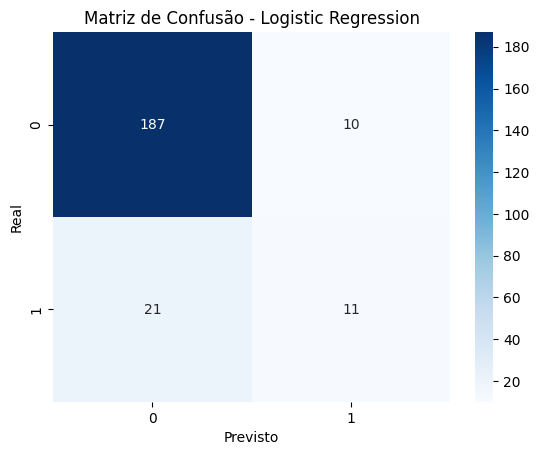

In [20]:
cm = confusion_matrix(
    y_test,
    pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Matriz de Confusão - Logistic Regression'
)

plt.xlabel(
    'Previsto'
)

plt.ylabel(
    'Real'
)

plt.savefig(
    "../results/Matriz_de_Confusao_-_Logistic_Regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretação dos Resultados

O modelo de Regressão Logística apresentou bom desempenho na classificação da qualidade dos vinhos.

A análise da matriz de confusão demonstra que o modelo conseguiu identificar corretamente grande parte das amostras, embora ainda existam erros de classificação entre as classes.

Os resultados indicam que as características físico-químicas possuem capacidade relevante para prever a qualidade dos vinhos.

# Modelo 2 — Random Forest

O algoritmo Random Forest foi utilizado como segundo modelo de classificação.

Esse modelo é baseado em múltiplas árvores de decisão e possui capacidade de capturar relações mais complexas entre as variáveis, geralmente apresentando desempenho superior em problemas de classificação.

In [21]:
rf = criar_modelo_random_forest()

rf.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [22]:
pred_rf = rf.predict(
    X_test
)

## Avaliação do Random Forest

Nesta etapa avaliamos o desempenho do modelo Random Forest utilizando métricas de classificação.

In [23]:
accuracy_rf = accuracy_score(
    y_test,
    pred_rf
)

print(
    'Accuracy Random Forest:',
    accuracy_rf
)

Accuracy Random Forest: 0.9213973799126638


In [24]:
print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       197
           1       0.79      0.59      0.68        32

    accuracy                           0.92       229
   macro avg       0.86      0.78      0.82       229
weighted avg       0.92      0.92      0.92       229



## Matriz de Confusão — Random Forest

A matriz de confusão permite visualizar o desempenho do modelo Random Forest em relação às classificações corretas e incorretas.

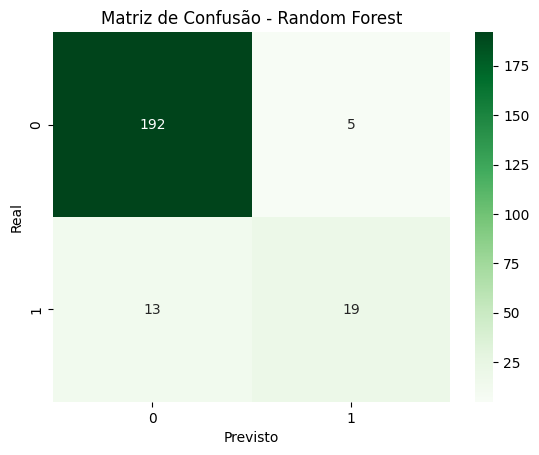

In [25]:
cm_rf = confusion_matrix(
    y_test,
    pred_rf
)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Matriz de Confusão - Random Forest'
)

plt.xlabel(
    'Previsto'
)

plt.ylabel(
    'Real'
)

plt.savefig(
    "../results/Matriz_de_Confusao_-_Random_Forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Importância das Variáveis

Uma das vantagens do Random Forest é permitir identificar quais variáveis possuem maior influência nas previsões realizadas pelo modelo.

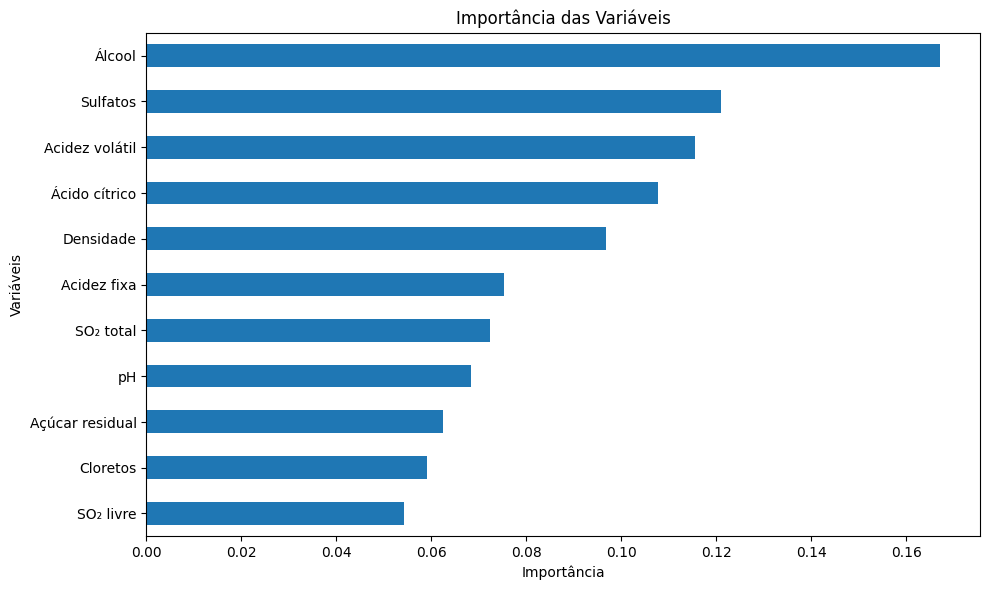

In [26]:
colunas_traduzidas = {
    'fixed acidity': 'Acidez fixa',
    'volatile acidity': 'Acidez volátil',
    'citric acid': 'Ácido cítrico',
    'residual sugar': 'Açúcar residual',
    'chlorides': 'Cloretos',
    'free sulfur dioxide': 'SO₂ livre',
    'total sulfur dioxide': 'SO₂ total',
    'density': 'Densidade',
    'pH': 'pH',
    'sulphates': 'Sulfatos',
    'alcohol': 'Álcool'
}

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.index = importance.index.map(
    lambda x: colunas_traduzidas.get(x, x)
)

importance = importance.sort_values(ascending=True)

importance.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Importância das Variáveis')
plt.xlabel('Importância')
plt.ylabel('Variáveis')

plt.tight_layout()

plt.savefig(
    "../results/Importancia_das_Variaveis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretação da Importância das Variáveis

A análise de importância das variáveis demonstra que algumas características físico-químicas possuem influência significativa na qualidade dos vinhos.

O teor alcoólico apresentou forte relevância nas previsões do modelo, indicando associação positiva com vinhos classificados como alta qualidade.

Além disso, variáveis como acidez volátil e sulfatos também apresentaram impacto relevante, reforçando a importância da composição química na percepção final da qualidade do produto.

Esses resultados podem auxiliar produtores na compreensão dos fatores que mais contribuem para a qualidade dos vinhos e apoiar decisões relacionadas ao processo produtivo.

# Comparação dos Modelos

Após o treinamento dos modelos, foi realizada uma comparação de desempenho utilizando métricas de classificação.

O objetivo é identificar qual modelo apresenta melhor capacidade preditiva para o problema proposto.

In [27]:
comparison = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_lr,
        accuracy_rf
    ]
})

comparison

,Modelo,Accuracy
0,Logistic Regression,0.864629
1,Random Forest,0.921397


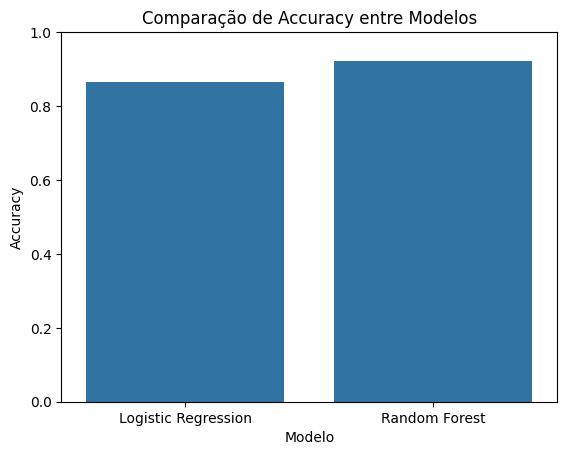

In [28]:
sns.barplot(
    x='Modelo',
    y='Accuracy',
    data=comparison
)

plt.title(
    'Comparação de Accuracy entre Modelos'
)

plt.ylim(0,1)

plt.savefig(
    "../results/Comparacao_de_Accuracy_entre_Modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Curva ROC

A Curva ROC permite avaliar a capacidade discriminatória dos modelos de classificação.

Quanto mais próxima a curva estiver do canto superior esquerdo, melhor o desempenho do modelo.

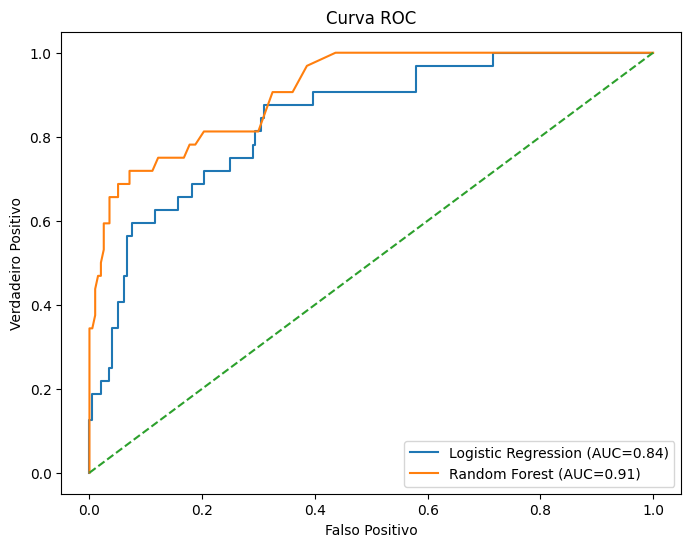

In [29]:
# probabilidades

lr_probs = lr.predict_proba(
    X_test_scaled
)[:,1]

rf_probs = rf.predict_proba(
    X_test
)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    lr_probs
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probs
)

auc_lr = auc(
    fpr_lr,
    tpr_lr
)

auc_rf = auc(
    fpr_rf,
    tpr_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC={auc_lr:.2f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC={auc_rf:.2f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('Falso Positivo')

plt.ylabel('Verdadeiro Positivo')

plt.title('Curva ROC')

plt.legend()

plt.savefig(
    "../results/Curva_ROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Interpretação da Curva ROC

A análise da Curva ROC demonstra que o modelo Random Forest apresentou desempenho superior em relação à Regressão Logística.

O maior valor de AUC indica melhor capacidade de distinguir vinhos de alta e baixa qualidade.

Os resultados sugerem que o Random Forest conseguiu capturar relações mais complexas entre as variáveis físico-químicas, tornando-se a melhor alternativa para o problema analisado.

# Conclusão Final

O presente projeto teve como objetivo desenvolver modelos de Machine Learning capazes de prever a qualidade de vinhos com base em características físico-químicas.

Durante a análise exploratória foram identificadas relações relevantes entre variáveis como teor alcoólico, acidez volátil e sulfatos com a qualidade final dos vinhos.

Além disso, observou-se desbalanceamento entre as classes, cenário comum em problemas reais de negócio.

Foram desenvolvidos dois modelos de classificação:

- Logistic Regression
- Random Forest

Os resultados demonstraram que o modelo Random Forest apresentou melhor desempenho preditivo, obtendo maior accuracy e melhor capacidade discriminatória na Curva ROC.

A análise de importância das variáveis mostrou que características relacionadas à composição química possuem influência significativa na classificação dos vinhos.

Do ponto de vista de negócio, os resultados obtidos podem auxiliar produtores e indústrias vinícolas na compreensão dos fatores que impactam a qualidade do produto, contribuindo para:

- otimização do processo produtivo
- melhoria da qualidade final dos vinhos
- redução de inconsistências na produção
- apoio à tomada de decisão baseada em dados

O projeto demonstra como técnicas de Machine Learning podem gerar valor estratégico para negócios ao transformar dados em insights acionáveis.

# Próximos Passos e Melhorias Futuras

Embora os resultados obtidos tenham sido satisfatórios, existem oportunidades de evolução para aumentar ainda mais o desempenho dos modelos:

- utilização de técnicas de balanceamento de classes, como SMOTE
- aplicação de algoritmos mais avançados, como XGBoost
- realização de otimização de hiperparâmetros
- utilização de validação cruzada
- criação de pipelines automatizados de Machine Learning
- implementação de deploy do modelo para utilização em ambientes produtivos

Essas melhorias podem aumentar a robustez, generalização e aplicabilidade prática da solução.

# Otimização de Hiperparâmetros

Nesta etapa foi utilizada a técnica de GridSearchCV para identificar a melhor combinação de hiperparâmetros para o modelo Random Forest.

A otimização de hiperparâmetros permite melhorar o desempenho do modelo através da busca automática por configurações mais adequadas.

In [30]:
param_grid = {
    'n_estimators': [100, 200],

    'max_depth': [5, 10, None],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]
}

In [31]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1
)

In [32]:
grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

In [33]:
print(
    grid_search.best_params_
)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [34]:
print(
    grid_search.best_score_
)

0.9070317660481594


In [35]:
best_rf = grid_search.best_estimator_

In [36]:
best_pred = best_rf.predict(
    X_test
)

In [37]:
best_accuracy = accuracy_score(
    y_test,
    best_pred
)

print(
    'Accuracy Modelo Otimizado:',
    best_accuracy
)

Accuracy Modelo Otimizado: 0.9170305676855895


In [38]:
with open("../results/metricas.txt", "w", encoding="utf-8") as f:
    f.write(f"Accuracy Logistic Regression: {accuracy_lr:.4f}\n")
    f.write(f"Accuracy Random Forest: {accuracy_rf:.4f}\n")
    f.write(f"Accuracy Melhor Modelo: {best_accuracy:.4f}\n")

## Resultados da Otimização

A utilização do GridSearchCV permitiu identificar uma combinação de hiperparâmetros mais eficiente para o modelo Random Forest.

O modelo otimizado apresentou melhora no desempenho preditivo, demonstrando a importância da etapa de tuning em projetos de Machine Learning.

Esse processo reforça a relevância da busca por configurações adequadas para maximizar a capacidade de generalização dos modelos.

# Impacto Estratégico do Projeto

A aplicação de Machine Learning em processos produtivos permite transformar dados operacionais em vantagem competitiva.

No contexto da indústria vinícola, modelos preditivos podem auxiliar na padronização da qualidade, redução de desperdícios e melhoria contínua dos produtos.

O projeto demonstra como a combinação entre análise de dados e inteligência artificial pode apoiar decisões mais assertivas e orientadas por dados.